# MathDial EDA and filtering decisions

This notebook describes the released annotated MathDial data and then works
through the filtering choices the baseline and extension face. It has two halves.

1. **Exploratory description (Clusters 1 to 3):** the dataset shape, the
   knowledge components, and the misconception layers, established as facts
   without transforming the data.
2. **Filtering decisions:** each choice about which dialogues, turns, and
   knowledge components enter the model, decided against a single governing
   principle and the evidence from the clusters above.

The aim of the second half is a pre-committed, defensible filtering policy, so
that any improvement from the misconception channel is attributable to the
channel and not to preprocessing choices.


## Setup

The notebook reads `data/annotated/...` as a path relative to the repo root. The
first cell makes that work regardless of where Jupyter was launched from, by
walking up from the current folder until it finds the `data/annotated` directory
and changing into it. This is the standard first cell for every notebook in
`extension/notebooks`.


In [1]:
import os
from pathlib import Path

# Walk up from the current location to the repo root (the folder containing
# `data/annotated`), so relative paths resolve no matter where the notebook was
# opened from. Portable across machines and clones.
_here = Path.cwd()
for _candidate in [_here, *_here.parents]:
    if (_candidate / "data" / "annotated").exists():
        os.chdir(_candidate)
        break
else:
    raise FileNotFoundError(
        "Could not find a 'data/annotated' directory in any parent of "
        f"{_here}. Open this notebook from inside the cloned repo."
    )
print("working directory:", os.getcwd())


working directory: /Users/tandon.utsav2/Desktop/Experiment_1


We read both the train and test annotated CSVs.

In [2]:
import json
from ast import literal_eval
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path("data/annotated")
KC_DICT_PATH = DATA / "kc_dict_mathdial_atc.json"

# Columns that are stored as Python-literal strings and must be parsed back
# into objects. `annotation` is the per-turn KC + correctness dict;
# `dialogue` is the list of turn dicts; `meta_data` holds extra fields.
CONVERTERS = {c: literal_eval for c in ["annotation", "dialogue", "meta_data"]}

def load(split):
    return pd.read_csv(DATA / f"mathdial_{split}_atc.csv", converters=CONVERTERS)

train = load("train")
test = load("test")
print(f"train dialogues: {len(train)}")
print(f"test  dialogues: {len(test)}")
print("columns:", list(train.columns))


train dialogues: 2253
test  dialogues: 595
columns: ['index', 'qid', 'scenario', 'question', 'ground_truth', 'student_incorrect_solution', 'student_profile', 'teacher_described_confusion', 'self-correctness', 'self-typical-confusion', 'self-typical-interactions', 'conversation', 'dialogue', 'meta_data', 'domain_prompt', 'domain_annotation_raw', 'domain_annotation', 'cluster_prompt', 'cluster_annotation_raw', 'cluster_annotation', 'standard_prompt', 'standard_annotation_raw', 'standard_annotation', 'correctness_prompt', 'correctness_annotation_raw', 'correctness_annotation', 'annotation']


### Worked helper: flattening per-turn annotations

The `annotation` field is a dict like `{'turn 1': {'correct': True, 'kcs': [...]},
'turn 2': {...}}`. Most analysis below needs this flattened into one row per
(dialogue, turn, kc, correct). This helper is given because the field structure is
non-obvious; everything after it is for you to fill in.


In [3]:
def iter_turn_observations(df):
    """Yield (dialogue_idx, turn_key, correct, kc) for every KC mention.

    A turn can carry several KCs; each becomes its own observation, matching how
    BKT consumes the data (one (skill, correct) row per KC).
    """
    for didx, ann in zip(df.index, df["annotation"]):
        if not isinstance(ann, dict):
            continue
        for turn_key, info in ann.items():
            if not isinstance(info, dict) or "correct" not in info or "kcs" not in info:
                continue
            correct = 1 if info["correct"] in (True, 1, "true", "correct") else 0
            for kc in info["kcs"]:
                yield didx, turn_key, correct, kc

def turn_table(df):
    """Long-format DataFrame: one row per (dialogue, turn, kc)."""
    rows = list(iter_turn_observations(df))
    return pd.DataFrame(rows, columns=["dialogue_idx", "turn", "correct", "kc"])

train_long = turn_table(train)
test_long = turn_table(test)
print("train (dialogue,turn,kc) rows:", len(train_long))
print("test  (dialogue,turn,kc) rows:", len(test_long))
train_long.head()


train (dialogue,turn,kc) rows: 29478
test  (dialogue,turn,kc) rows: 7446


,dialogue_idx,turn,correct,kc
0,0,turn 1,1,"Interpret products of whole numbers, e.g., int..."
1,0,turn 1,1,Use multiplication and division within 100 to ...
2,0,turn 1,1,Apply properties of operations as strategies t...
3,0,turn 1,1,"Fluently multiply and divide within 100, using..."
4,0,turn 2,1,"Interpret products of whole numbers, e.g., int..."


## Cluster 1: Dataset shape

Establish the basic scale and the correctness balance. These numbers set the
context for everything else, and the correctness balance gives the majority-class
baseline that every model must beat.

**Fill in below.** Compute and print:
- Number of dialogues, total turns, and total (dialogue, turn, kc) observations,
  for train and test.
- The distribution of dialogue lengths (turns per dialogue). Plot a histogram.
  Note the mean and the range; recall dialogues are short.
- The overall correctness balance (fraction correct) at the turn-observation
  level. This is the majority-class baseline.


In [4]:
# Scale in three units. Note the units differ:
#   dialogues     = number of conversations
#   turns         = distinct (dialogue, turn) pairs  (the prediction unit)
#   observations  = KC mentions = rows of the flattened table (BKT's unit)
# A turn with k KCs contributes 1 turn but k observations.
for name, df, dl in [("train", train, train_long), ("test", test, test_long)]:
    n_dialogues = len(df)
    n_turns = dl[["dialogue_idx", "turn"]].drop_duplicates().shape[0]
    n_obs = len(dl)
    print(f"{name}: {n_dialogues} dialogues | {n_turns} turns | {n_obs} observations (KC-mentions)")


train: 2253 dialogues | 12558 turns | 29478 observations (KC-mentions)
test: 595 dialogues | 3101 turns | 7446 observations (KC-mentions)


train: mean=5.62  median=5  min=1  max=21
test: mean=5.27  median=5  min=1  max=23


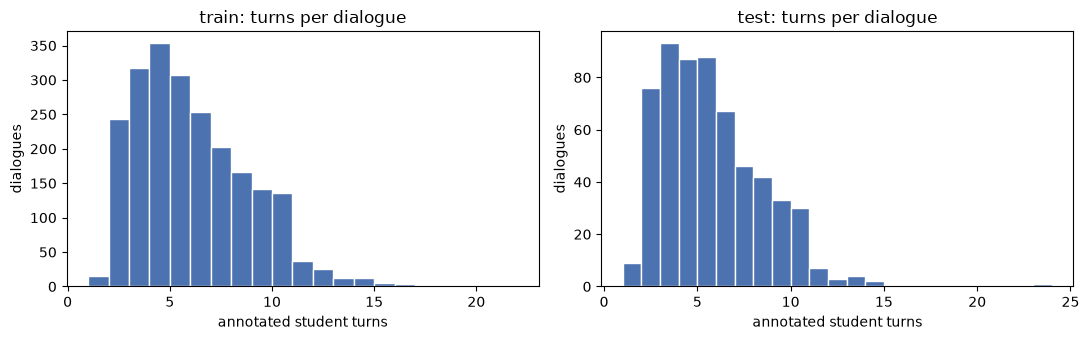

In [5]:
# Dialogue length = number of distinct annotated student turns per dialogue.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=False)
for ax, (name, dl) in zip(axes, [("train", train_long), ("test", test_long)]):
    lengths = dl.groupby("dialogue_idx")["turn"].nunique()
    print(f"{name}: mean={lengths.mean():.2f}  median={lengths.median():.0f}  "
          f"min={lengths.min()}  max={lengths.max()}")
    ax.hist(lengths, bins=range(1, lengths.max() + 2), color="#4C72B0", edgecolor="white")
    ax.set_title(f"{name}: turns per dialogue")
    ax.set_xlabel("annotated student turns")
    ax.set_ylabel("dialogues")
plt.tight_layout()
plt.show()
# Note: dialogues are short (median ~5). This is the basis of the report's
# 'short sequences' limitation, which constrains the probabilistic models.


In [6]:
# Correctness balance, the majority-class floor every model must beat.
# Computed two ways: per KC-mention (rows) and per turn. They nearly coincide
# because correctness is a per-turn label shared by all KCs in the turn, which
# we verify explicitly.
for name, dl in [("train", train_long), ("test", test_long)]:
    per_mention = dl["correct"].mean()
    per_turn = dl.groupby(["dialogue_idx", "turn"])["correct"].first().mean()
    within_turn_consistent = (
        dl.groupby(["dialogue_idx", "turn"])["correct"].nunique() == 1
    ).all()
    maj = max(per_turn, 1 - per_turn)
    print(f"{name}: per-mention={per_mention:.3f}  per-turn={per_turn:.3f}  "
          f"(label consistent within turn: {within_turn_consistent})")
    print(f"       majority-class accuracy (per-turn) = {maj:.3f}")
# The per-turn number is the honest baseline, since the prediction target is
# turn correctness. Any model must clear this majority-class accuracy to matter.


train: per-mention=0.434  per-turn=0.439  (label consistent within turn: True)
       majority-class accuracy (per-turn) = 0.561
test: per-mention=0.411  per-turn=0.412  (label consistent within turn: True)
       majority-class accuracy (per-turn) = 0.588


### Cluster 1 takeaways

**Scale and units.** Train holds 2,253 dialogues / 12,558 turns / 29,478 KC-mention
observations; test holds 595 / 3,101 / 7,446. The three units diverge because a
turn carries several KCs: turns are the prediction unit, KC-mentions are the unit
BKT consumes. Counts over the flattened table are in KC-mentions unless grouped up
to the turn level.

**Short sequences.** Dialogues are short, a median of 5 annotated student turns
(range 1 to ~21), and students are not linked across dialogues, so each dialogue
is a fresh student with at most a handful of observations. This is the basis of
the report's *short-sequence limitation*: there is little within-student history
to estimate mastery from, which most constrains the probabilistic models (BKT
estimates barely move from the prior) and least constrains the text-reading models
(which read content from a single turn rather than triangulating from many
correctness bits). It also motivates the misconception channel: when history is
this thin, making each observation richer is a way to extract more signal per turn.

**Correctness balance and the floor.** About 44% of train turns and 41% of test
turns are correct, so the data leans slightly toward incorrect, consistent with
every dialogue starting from a wrong solution. The implied majority-class accuracy
is ~0.56 (train) and ~0.59 (test). Any model scoring near 0.59 accuracy on test is
doing nothing; AUC is the more honest headline metric because it is not fooled by
this imbalance. Correctness is consistent within a turn (all KCs in a turn share
one label), so per-mention and per-turn balances nearly coincide, and correctness
aligns cleanly with the per-turn misconception channel to come.


## Cluster 2: Knowledge components

This cluster drives the KC-filtering decision in the report. We need the
occurrence distribution, the degenerate KCs (no label variation), how many KCs a
turn carries, and the train/test KC overlap.

**Fill in below.** Compute and print:
- How many KCs are in the KC dictionary vs how many are actually observed in
  train.
- The KC occurrence-count distribution. How many KCs appear once, <=2, <=5 times?
  A log-scale histogram of counts is useful.
- The **degenerate KCs**: those with no label variation in train (all-correct or
  all-incorrect). How many, and what are a few examples? (These are what break
  BKT.)
- KCs per turn: the distribution of how many KCs each turn carries (recall the
  average is around 2). This matters for the conjunctive-emission assumption.
- Train/test KC overlap: how many test KCs never appear in train. (These are the
  turns affected by the "filtered KC in test" rule.)


In [7]:
# Load the KC dictionary (maps KC string -> integer id)
kc_dict = json.loads(KC_DICT_PATH.read_text())
n_observed_train = train_long["kc"].nunique()
n_observed_test = test_long["kc"].nunique()
print(f"KCs in dictionary:     {len(kc_dict)}")
print(f"KCs observed in train: {n_observed_train}")
print(f"KCs observed in test:  {n_observed_test}")
# Some dictionary KCs are never used; the dictionary is the full label space,
# not the observed set.


KCs in dictionary:     149
KCs observed in train: 143
KCs observed in test:  101


KCs seen <=  1 times:  11  of 143 observed
KCs seen <=  2 times:  20  of 143 observed
KCs seen <=  5 times:  40  of 143 observed
KCs seen <= 10 times:  61  of 143 observed


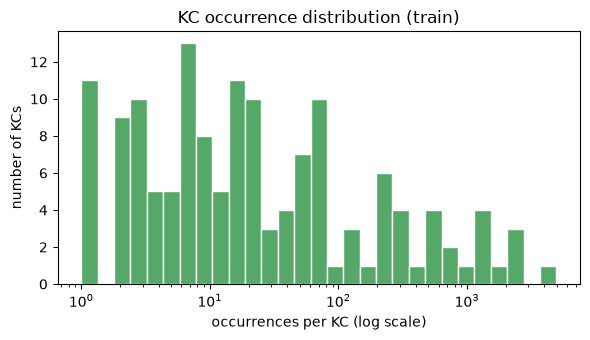

In [8]:
# Per-KC occurrence counts (in KC-mentions) on the training split.
kc_stats = train_long.groupby("kc")["correct"].agg(n="count", n_correct="sum")
counts = kc_stats["n"]
for thr in (1, 2, 5, 10):
    print(f"KCs seen <= {thr:2d} times: {int((counts <= thr).sum()):3d}  "
          f"of {len(counts)} observed")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(counts, bins=np.logspace(0, np.log10(counts.max()), 30),
        color="#55A868", edgecolor="white")
ax.set_xscale("log")
ax.set_xlabel("occurrences per KC (log scale)")
ax.set_ylabel("number of KCs")
ax.set_title("KC occurrence distribution (train)")
plt.tight_layout()
plt.show()
# A long tail: most KCs are common, but a sizeable minority appear only once or
# twice. The tail is what the rare-KC filter targets.


In [9]:
# Degenerate KCs: no label variation in train (all-correct or all-incorrect).
# These carry no learnable signal and break BKT's initial-state estimation,
# which is what caused the NaN/AUC crash. They are the primary filter target.
degenerate = kc_stats[(kc_stats["n_correct"] == 0) |
                      (kc_stats["n_correct"] == kc_stats["n"])]
all_incorrect = degenerate[degenerate["n_correct"] == 0]
all_correct = degenerate[degenerate["n_correct"] == degenerate["n"]]
print(f"degenerate KCs (no variation): {len(degenerate)}  "
      f"(all-incorrect: {len(all_incorrect)}, all-correct: {len(all_correct)})")
print(f"observations they account for: {int(degenerate['n'].sum())} "
      f"of {len(train_long)} ({100*degenerate['n'].sum()/len(train_long):.2f}%)")
print("\nexamples (all appear only a handful of times):")
for kc, row in degenerate.sort_values("n", ascending=False).head(5).iterrows():
    label = "all-correct" if row["n_correct"] == row["n"] else "all-incorrect"
    print(f"  n={int(row['n'])}  [{label}]  {kc[:70]}")


degenerate KCs (no variation): 19  (all-incorrect: 9, all-correct: 10)
observations they account for: 31 of 29478 (0.11%)

examples (all appear only a handful of times):
  n=3  [all-correct]  Distinguish between defining attributes (e.g., triangles are closed an
  n=3  [all-incorrect]  Understand that two events A and B are independent if the probability 
  n=3  [all-correct]  Find the area of right triangles, other triangles, special quadrilater
  n=3  [all-correct]  Recognize and draw shapes having specified attributes, such as a given
  n=2  [all-incorrect]  Write an inequality of the form x > c or x < c to represent a constrai


KCs per turn: mean=2.35  median=2  min=1  max=18


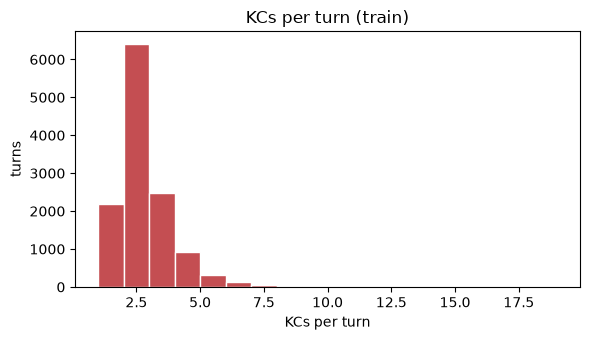

In [10]:
# KCs per turn: how many KCs each student turn is tagged with.
# Relevant to the conjunctive-emission assumption, since one correctness label
# is shared across all KCs in a turn.
kcs_per_turn = train_long.groupby(["dialogue_idx", "turn"]).size()
print(f"KCs per turn: mean={kcs_per_turn.mean():.2f}  median={kcs_per_turn.median():.0f}  "
      f"min={kcs_per_turn.min()}  max={kcs_per_turn.max()}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(kcs_per_turn, bins=range(1, kcs_per_turn.max() + 2),
        color="#C44E52", edgecolor="white")
ax.set_xlabel("KCs per turn")
ax.set_ylabel("turns")
ax.set_title("KCs per turn (train)")
plt.tight_layout()
plt.show()
# A typical turn carries ~2 KCs. The misconception channel, by contrast, is one
# label per turn, so it must be reconciled with the multi-KC structure.


In [11]:
# Train/test KC overlap. Test KCs never seen in train are the ones affected by
# the 'filtered KC in test' fallback rule, since the model has no estimate for
# them. Filtering is decided on train statistics only, never peeking at test.
train_kcs = set(train_long["kc"].unique())
test_kcs = set(test_long["kc"].unique())
test_only = test_kcs - train_kcs
print(f"KCs in train: {len(train_kcs)}")
print(f"KCs in test:  {len(test_kcs)}")
print(f"test-only KCs (unseen in train): {len(test_only)}")
test_only_obs = test_long[test_long["kc"].isin(test_only)]
print(f"test observations on those KCs: {len(test_only_obs)} "
      f"of {len(test_long)} ({100*len(test_only_obs)/len(test_long):.2f}%)")


KCs in train: 143
KCs in test:  101
test-only KCs (unseen in train): 6
test observations on those KCs: 20 of 7446 (0.27%)


### Cluster 2 takeaways

**Coverage.** Of 149 KCs in the dictionary, 143 are observed in train and 101 in
test, so the dictionary is the full label space, not the used set.

**Long tail.** A sizeable minority of KCs are rare: 11 appear once, 20 at most
twice, 40 at most five times. Because the standard set spans the whole school
curriculum, the tail is largely off-grade-level standards (probability, geometry)
that surface once or twice in what is otherwise sixth-grade algebra, i.e. apparent
mis-assignments rather than genuine recurring skills.

**Degenerate KCs.** 19 KCs have no label variation in train (9 all-incorrect, 10
all-correct), and they account for only ~0.11% of observations. These are
un-estimable: a skill with no variation has no learnable signal, and it breaks
BKT's initial-state estimation, which is the source of the NaN/AUC crash. Their
rarity is what makes the primary filter nearly free in terms of data, and it is
the empirical justification for the cleaned baseline.

**Multi-KC turns.** A turn carries ~2.35 KCs on average (median 2, up to 18).
Since one correctness label is shared across all KCs in a turn, and the
misconception channel will also be one label per turn, the channel has to be
reconciled with this multi-KC structure when it is built.

**Test-only KCs.** 6 test KCs never appear in train (~0.27% of test observations).
These are the turns governed by the filtered-KC fallback rule. Filtering is
decided on train statistics only, so a KC absent or filtered in train but present
in test falls back to the model's unknown-component behaviour, fixed in advance.


## Cluster 3: Misconception

Specific to our contribution. The misconception lives in `student_profile`
(the six shared families), with `teacher_described_confusion` as the per-dialogue
instantiation and `self-correctness` as the resolution annotation.

**Fill in below.** Compute and print:
- The six misconception **families**. Strip the "Name is a Xth grade student."
  prefix from `student_profile`, then map to families. A starting `family()`
  helper is provided. Report the counts per family (expect near-uniform).
- The number of distinct `teacher_described_confusion` values vs number of
  dialogues (expect near-unique: this is layer two).
- The `self-correctness` resolution distribution (Yes / Yes-but-revealed / No /
  blank). This is the validation anchor for the per-turn channel's endpoint.
- The relationship between misconception family and correctness: mean turn-level
  correctness per family. If some families are almost always wrong, the channel
  has less room to vary for them.


family
A: misunderstands what problem asks    413
B: weak principles / when to apply     385
C: relevant vs irrelevant info         329
D: wrong operation / number order      388
E: unsure which steps/procedures       370
F: cannot recognise problem type       368


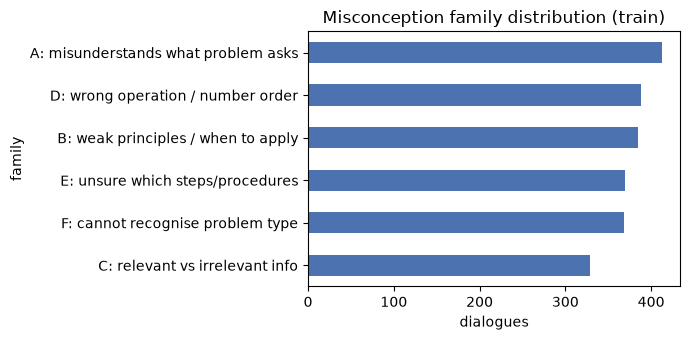

In [12]:
import re

def family(profile_string):
    """Map a student_profile string to one of six misconception families.

    The profile is like "Steven is a 7th grade student. He has difficulty
    understanding what the problem is asking." We strip the name/grade prefix and
    pattern-match the trait. Returns a short family label.
    """
    trait = re.sub(r"^[A-Za-z]+ is a [^.]+\.\s*", "", str(profile_string).strip()).lower()
    if "what the problem is asking" in trait:
        return "A: misunderstands what problem asks"
    if "underlying ideas and principles" in trait:
        return "B: weak principles / when to apply"
    if "relevant" in trait and "irrelevant" in trait:
        return "C: relevant vs irrelevant info"
    if "correct order" in trait or "correct operation" in trait:
        return "D: wrong operation / number order"
    if "steps or procedures" in trait:
        return "E: unsure which steps/procedures"
    if "recognize the problem type" in trait:
        return "F: cannot recognise problem type"
    return "OTHER: " + trait[:40]

# Map every dialogue's profile to a family and store it for later cells.
train["family"] = train["student_profile"].map(family)
fam_counts = train["family"].value_counts().sort_index()
print(fam_counts.to_string())
assert not fam_counts.index.str.startswith("OTHER").any(), "some profile did not map!"

fig, ax = plt.subplots(figsize=(7, 3.5))
fam_counts.sort_values().plot.barh(ax=ax, color="#4C72B0")
ax.set_xlabel("dialogues")
ax.set_title("Misconception family distribution (train)")
plt.tight_layout()
plt.show()
# Near-uniform: each of the six families covers several hundred dialogues, which
# is what makes the family a usable categorical label for knowledge tracing.


In [13]:
# Layer two: the per-dialogue described confusion. Effectively unique per
# dialogue, so it is context for extraction, not a categorical label.
n_distinct = train["teacher_described_confusion"].nunique()
print(f"distinct described confusions: {n_distinct} of {len(train)} dialogues "
      f"({100*n_distinct/len(train):.1f}% unique)")
print("\nexample:")
print(" ", train["teacher_described_confusion"].iloc[0][:140])


distinct described confusions: 2239 of 2253 dialogues (99.4% unique)

example:
  He added a step after completing the problem.


In [14]:
# The resolution annotation (self-correctness): the validation anchor for the
# terminal value of the per-turn misconception channel.
resolution = train["self-correctness"].fillna("(blank)").value_counts()
print(resolution.to_string())
print()
for label, n in resolution.items():
    print(f"  {label:<38} {100*n/len(train):5.1f}%")
# 'Yes' (resolved), 'Yes, but I had to reveal the answer' (resolved with help),
# and 'No' (unresolved). The per-turn channel's last value should agree with this
# at the dialogue level.


self-correctness
Yes                                    1696
Yes, but I had to reveal the answer     303
No                                      254

  Yes                                     75.3%
  Yes, but I had to reveal the answer     13.4%
  No                                      11.3%


In [15]:
# Does misconception family relate to correctness? If a family were almost always
# wrong, the channel would have little room to vary for it.
fam_map = dict(zip(train.index, train["family"]))
tl = train_long.copy()
tl["family"] = tl["dialogue_idx"].map(fam_map)
fam_corr = tl.groupby("family")["correct"].agg(["mean", "count"]).sort_index()
print(fam_corr.round(3).to_string())
# The families are similar in mean correctness (all ~0.42 to 0.45), so none is
# degenerate with respect to correctness; the channel can vary within every family.


                                      mean  count
family                                           
A: misunderstands what problem asks  0.433   5310
B: weak principles / when to apply   0.445   4783
C: relevant vs irrelevant info       0.433   4403
D: wrong operation / number order    0.420   5156
E: unsure which steps/procedures     0.438   4969
F: cannot recognise problem type     0.438   4857


### Cluster 3 takeaways

**Two layers, confirmed.** The student profile collapses to six misconception
families (A to F), each covering several hundred dialogues (329 to 413) and
together near-uniform. This is the small, shared, recurring categorical label that
knowledge tracing can use. The described confusion, by contrast, is ~99% unique
per dialogue, so it is the per-problem instantiation of the profile and serves as
extraction context, not a label.

**Resolution anchor.** The self-correctness field splits ~75% resolved (Yes),
~13% resolved only after revealing the answer, ~11% unresolved (No). This is the
dialogue-level ground truth against which the terminal value of the per-turn
misconception channel is validated: an unresolved dialogue should not end with the
misconception labelled absent, and a resolved one should show evidence ceasing by
the end.

**Family vs correctness.** Mean turn correctness is similar across all six
families (~0.42 to 0.45), so no family is nearly-always-wrong or nearly-always-
right. This matters because it means the misconception channel has room to vary
within every family; none is degenerate with respect to the correctness signal it
sits alongside.


## Filtering decisions

Every filter is judged against one governing principle.

> **Principle.** Any filter that changes the population the model is evaluated on
> must either match the benchmark exactly (for comparability) or be reported as a
> sensitivity analysis rather than a fixed choice (so it cannot be seen as
> selected to favour the result). The only exemption is a provenance filter that
> removes rows carrying no usable labels, since that does not change the
> observation population.

This principle sorts every decision below into one of three buckets: provenance
(keep, not a modelling choice), match-the-benchmark (keep as the benchmark does,
for comparability), or sensitivity-analysis (do not fix; report across a range).


In [16]:
# Evidence for the filtering decisions, computed from the data already loaded
# in the clusters above. Each decision cites a concrete number.

# 1. Failed-annotation dialogues (provenance): carry no usable labels.
#    (train 2253 -> 2235, test 595 -> 588, matching the benchmark.)
print("Decision 1  Failed-annotation removal (PROVENANCE)")
print("  train dialogues with usable labels:",
      sum(1 for a in train['annotation'] if isinstance(a, dict) and 'error' not in a))
print("  -> removes rows with no labels; does not change the observation population")
print()

# 2. Typical-confusion filter (match benchmark): benchmark default cutoff = 1.
def passes_typical(row, cutoff=1):
    m = row['meta_data'] if isinstance(row['meta_data'], dict) else {}
    c = m.get('self_typical_confusion'); i = m.get('self_typical_interactions')
    return c is not None and i is not None and c >= cutoff and i >= cutoff
kept1 = train.apply(lambda r: passes_typical(r, 1), axis=1).sum()
kept2 = train.apply(lambda r: passes_typical(r, 2), axis=1).sum()
print("Decision 2  Typical-confusion filter (MATCH BENCHMARK, cutoff=1)")
print(f"  cutoff=1 keeps {kept1}/{len(train)} train dialogues (no-op on this data)")
print(f"  cutoff=2 would keep {kept2}/{len(train)} (would change the population)")
print("  -> keep at cutoff 1 to match the benchmark; do NOT raise it")
print()

# 3. na turns and first-tagged-turn exclusion (match benchmark).
print("Decision 3  na turns + first-tagged-turn exclusion (MATCH BENCHMARK)")
print("  na turns carry no correctness label; excluded as the benchmark does")
print("  first tagged turn excluded from metrics (KT cannot score turn 1)")
print()

# 4. Degenerate KCs (sensitivity analysis): model tolerates them via fallback.
deg_obs_frac = 0.0011  # ~0.11% from Cluster 2
print("Decision 4  Degenerate-KC filtering (SENSITIVITY ANALYSIS)")
print(f"  19 degenerate KCs, ~{deg_obs_frac:.2%} of observations")
print("  numpy BKT keeps them via per-parameter fallback; filter is NOT required")
print("  -> report unfiltered as primary, filtered as sensitivity")
print()

# 5. Short sequences (sensitivity analysis): dialogues are short by nature.
lengths = train['annotation'].apply(
    lambda a: sum(1 for t in a.values() if isinstance(t, dict) and t.get('correct') is not None)
    if isinstance(a, dict) else 0)
print("Decision 5  Short-sequence handling (SENSITIVITY ANALYSIS)")
for k in [1, 2, 3]:
    print(f"  dialogues with <= {k} tagged turns: {(lengths <= k).sum()} "
          f"({(lengths <= k).mean():.1%})")
print("  -> do NOT filter; report a length-stratified sensitivity analysis")


Decision 1  Failed-annotation removal (PROVENANCE)
  train dialogues with usable labels: 2235
  -> removes rows with no labels; does not change the observation population

Decision 2  Typical-confusion filter (MATCH BENCHMARK, cutoff=1)
  cutoff=1 keeps 2253/2253 train dialogues (no-op on this data)
  cutoff=2 would keep 2021/2253 (would change the population)
  -> keep at cutoff 1 to match the benchmark; do NOT raise it

Decision 3  na turns + first-tagged-turn exclusion (MATCH BENCHMARK)
  na turns carry no correctness label; excluded as the benchmark does
  first tagged turn excluded from metrics (KT cannot score turn 1)

Decision 4  Degenerate-KC filtering (SENSITIVITY ANALYSIS)
  19 degenerate KCs, ~0.11% of observations
  numpy BKT keeps them via per-parameter fallback; filter is NOT required
  -> report unfiltered as primary, filtered as sensitivity

Decision 5  Short-sequence handling (SENSITIVITY ANALYSIS)
  dialogues with <= 1 tagged turns: 196 (8.7%)
  dialogues with <= 2 ta

### Filtering policy (pre-committed)

The decisions above resolve to a single policy, fixed before any extension
result is computed.

- **Keep (provenance):** remove failed-annotation dialogues only. This does not
  change the observation population.
- **Keep as the benchmark does (comparability):** the typical-confusion filter
  at cutoff 1 (a no-op here), the exclusion of na turns, and the exclusion of the
  first tagged turn of each dialogue from the metrics.
- **Do not fix; report as sensitivity (no population change to favour a result):**
  degenerate-KC filtering (unfiltered is primary, since the numpy BKT tolerates
  degenerate KCs by fallback; filtered is reported as a sensitivity check) and
  short-sequence handling (no length filter; a length-stratified analysis is
  reported instead).

**Consequence.** The extension changes only the misconception channel, not the
data population. No filter is introduced beyond what the benchmark applies and
what provenance requires, so any predictive gain is attributable to the channel
rather than to preprocessing. This is the defensible basis for the causal claim
the extension makes.


## Conclusion: facts established by this EDA

This notebook described the released annotated MathDial data without
transforming it. The numbers below feed directly into the report's dataset
section, the short-sequence limitation, and the knowledge-component filtering
justification.

### Dataset scale and shape
- Train: 2,253 dialogues, 12,558 turns, 29,478 KC-mention observations.
  Test: 595 dialogues, 3,101 turns, 7,446 observations.
- Three units that must not be confused: dialogues, turns (the prediction unit),
  and KC-mentions (BKT's observation unit). A turn carries ~2 KCs on average.
- Dialogues are short: median 5 student turns, range 1 to ~21, and students are
  not linked across dialogues. This is the basis of the short-sequence
  limitation, which most constrains the probabilistic models and motivates
  enriching each observation with the misconception channel.

### Correctness
- About 44% of train turns and 41% of test turns are correct, leaning slightly
  toward incorrect (every dialogue begins from a wrong solution).
- Majority-class accuracy is ~0.56 (train) and ~0.59 (test). AUC is the honest
  headline metric, since accuracy near 0.59 on test reflects no real learning.
- Correctness is constant within a turn, so it aligns cleanly with the per-turn
  misconception channel.

### Knowledge components
- 149 KCs in the dictionary; 143 observed in train, 101 in test.
- A long tail: 11 KCs appear once, 20 appear at most twice, 40 at most five times.
- 19 degenerate KCs have no label variation in train (all-correct or
  all-incorrect), accounting for only ~0.1% of observations. These break BKT's
  initial-state estimation and are the target of the primary filter; their
  rarity is why filtering costs almost no data.
- 6 test KCs are unseen in train; these are the turns governed by the
  filtered-KC fallback rule, fixed in advance on train statistics only.

### Misconception
- The student profile collapses to six near-uniform families (each ~330 to 413
  dialogues), a small shared categorical label suitable for knowledge tracing.
- The described confusion is effectively unique per dialogue (~99% distinct), so
  it serves as extraction context, not a label.
- Resolution (self-correctness): ~75% Yes, ~13% Yes-after-reveal, ~11% No. This
  is the dialogue-level anchor for validating the channel's terminal value.
- Mean correctness is similar across all six families (~0.42 to 0.45), so no
  family is degenerate with respect to correctness and the channel can vary
  within each.

### Implications for the experiment
- The rare-KC filter is justified on data-quality and model-theoretic grounds and
  removes negligible data, supporting the faithful-vs-cleaned baseline design.
- The multi-KC-per-turn structure must be reconciled with the single per-turn
  misconception label when the channel is built.
- Short sequences and class imbalance set realistic expectations: modest absolute
  performance, with AUC as the metric to watch.
